In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import rasterio
import os
from rasterio import features

import importlib
import dasymetric 
from dasymetric import DasymetricConfig, DasymetricRedistributor

In [3]:
with rasterio.open('data/gha_pop_2025.tif') as src:
    prf = src.profile
    trf = src.transform
    arr = src.read(1)
    bds = src.bounds

adm = gpd.read_file('data/gha_adm2.json')

val = [(geom, i+1) for i,geom in zip(adm.index.values, adm.geometry)]
mst = features.rasterize(
    val,
    out_shape=(prf['height'], prf['width']),
    transform=trf,
    fill=-1,
    dtype=np.int16
)

df = pd.DataFrame({'adm': mst.flatten(), 'pop': arr.flatten()})
sel = np.logical_and(df['adm'] > 0, df['pop'] > 0)
df = df[sel].groupby('adm').sum().reset_index(drop=False)

df.to_csv('data/gha_pop_2025.csv', index=False)
adm_ = adm[['geometry']].copy()
adm_['adm'] = adm.index.values + 1
mrg = pd.merge(df, adm_, on='adm', how='outer')
mrg = gpd.GeoDataFrame(mrg, geometry='geometry', crs=adm.crs)
mrg.to_file('data/gha_pop_2025.gpkg', index=False)

p = prf.copy()
p.update(dtype='int16', count=1, nodata=-1)
with rasterio.open('data/gha_adm2.tif', 'w', **p) as dst:
    dst.write(mst, 1)

p = prf.copy()
arr_ = (arr.copy() > 0).astype(np.uint8)
p.update(dtype='uint8', count=1, nodata=0)
with rasterio.open('data/bol_mask.tif', 'w', **p) as dst:
    dst.write(arr_, 1)

2026-07-28 17:35:33,228 [INFO] Created 260 records


In [46]:
with rasterio.open('out/gha_test_mastergrid.tif') as s:
    a = s.read(1)
    p = s.profile

#with rasterio.open('data/gha_mask.tif', 'w', **p) as d:
#    d.write(a, indexes=1)

In [26]:
importlib.reload(dasymetric)
from dasymetric import DasymetricConfig, DasymetricRedistributor

config = DasymetricConfig(
    weight_raster_path="data/gha_viirs_2023.tif",
    pop_path="data/gha_pop_2025.csv",
    #geom_path="out/gha_test_mastergrid.tif",
    geom_path="data/gha_pop_2025.gpkg",
    output_raster_path="out/gha_test.tif",
    pop_field="pop",
    #mask_path="data/gha_mask.tif",
    id_field="adm",
    nodata=-99999,
    #id_field="idx",     # optional; auto-generated if omitted
    block_size=1024,
    n_workers=4,
    max_windows=128
)

job = DasymetricRedistributor(config)
#job.run()

2026-07-31 21:23:34,706 [INFO] Creating mastergrid from vector layer...
2026-07-31 21:23:34,719 [INFO] Rasterizing mastergrid in a single pass (small raster)...


In [27]:
job.run()

2026-07-31 21:23:41,474 [INFO] Pass 1/2: computing per-zone weight sums (48 windows, 4 workers)
2026-07-31 21:23:43,154 [INFO] Pass 2/2: redistributing population (48 windows, 4 workers)
2026-07-31 21:23:43,158 [INFO] Redistributing population in a single pass (small raster)...
c:\Users\rhoro\miniconda3\envs\local\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*args, out=...)


done


In [8]:
def zonal_sum(rst_path, mst_path):
    with rasterio.open(rst_path) as rst, rasterio.open(mst_path) as mst:
        rst_arr = rst.read(1)
        rst_ndt = rst.nodata

        mst_arr = mst.read(1)
        mst_ndt = mst.nodata

    df = pd.DataFrame()
    df['idx'] = mst_arr.flatten()
    df['val'] = rst_arr.flatten()
    sel = np.logical_and(df.idx != mst_ndt, df.val != rst_ndt)
    df = df[sel]
    agg = df.groupby('idx').sum().reset_index()

    return agg

In [76]:
with rasterio.open('out/gha_test_mastergrid.tif') as s:
    a = s.read(1)
    ndt = s.nodata

In [77]:
lookup_dict = job._zone_sums.set_index('adm')["norm"].to_dict()
updater = np.vectorize(lambda x: lookup_dict.get(x, 0))
norm = updater(a)

In [28]:
pop_0 = zonal_sum('data/gha_pop_2025.tif', 'data/gha_adm2.tif')
pop_1 = zonal_sum('out/gha_test.tif', 'data/gha_adm2.tif')
viirs = zonal_sum('data/gha_viirs_2023.tif', 'data/gha_adm2.tif')


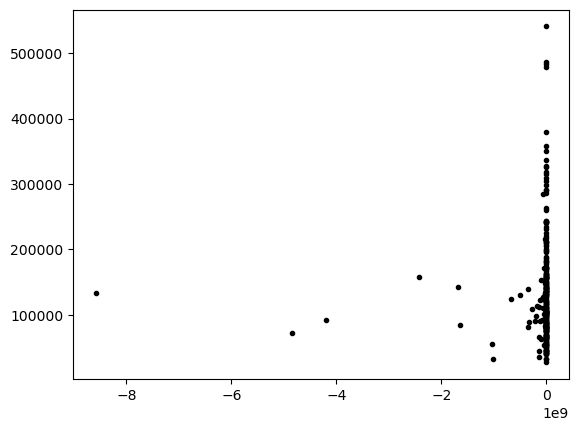

In [29]:
plt.plot(pop_1.val.values, pop_0.val.values, '.k')
plt.show()

In [18]:
d = pd.merge(a, b, on='idx')
d['ratio'] = d['val_x']/d['val_y']


In [19]:
d.describe()

c:\Users\rhoro\miniconda3\envs\local\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,idx,val_x,val_y,ratio
count,260.000000,260.000000,260.000000,260.000000
mean,130.500000,133532.125000,110430.593750,inf
std,75.199734,82933.921875,66619.507812,NaN
min,1.000000,26955.451172,0.000000,1.001077
25%,65.750000,80766.169922,69623.273438,1.047343
50%,130.500000,110884.078125,98749.914062,1.098289
75%,195.250000,157537.718750,138628.304688,1.191158
max,260.000000,541070.500000,415447.656250,inf
